# Benchmarking ExperimentDesigner

This notebook shows the lightweight workflow for profiling one live `ExperimentDesigner` run with `bed.benchmark.profile`. The profiler runs in the current Python process and samples memory while your callable executes.

`profile(...)` does three things:

- runs the callable you pass, such as `lambda: designer.calculateEIG(prior)`;
- samples process RSS memory on a background thread during that call;
- returns a `trace` dictionary with elapsed time, peak memory, metadata, and raw time-series samples.

The profiler is intentionally small: it is not a full subprocess/cold-start benchmark harness. It measures the live Python process you are already using, which is usually what you want in an interactive notebook.

By default here, everything is displayed inline and no files are written. For repeated comparisons or cold-start measurements, use a standalone script so each run can be configured and isolated explicitly.


In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from IPython.display import display

from bed.benchmark import combine_memory_traces, plot_timeseries, profile, summarize_trace
from bed.design import ExperimentDesigner
from bed.grid import Grid


In [2]:
def unnorm_lfunc(params, features, designs, **kwargs):
    y_mean = params.amplitude * jnp.sin(params.frequency * (designs.t_obs - params.offset))
    y_diff = features.y_obs - y_mean
    return jnp.exp(-0.5 * (y_diff / kwargs["sigma_y"]) ** 2)


designs = Grid(t_obs=jnp.linspace(0.0, 5.0, 51))
features = Grid(y_obs=jnp.linspace(-1.25, 1.25, 100))
params = Grid(
    amplitude=jnp.linspace(0.2, 2.0, 41),
    frequency=jnp.linspace(0.2, 2.0, 41),
    offset=jnp.linspace(0.2, 2.0, 41),
)
prior = params.normalize(jnp.ones(params.shape))


## Profile one EIG run

The output table reports total callable time and peak RSS memory. The time-series plot is built from `trace["samples"]`: `combine_memory_traces(...)` converts the raw samples into binned RSS deltas, and `plot_timeseries(...)` draws those deltas relative to the first memory sample at `t=0`.

{'label': 'calculateEIG',
 'call_elapsed_s': 6.497578292000981,
 'process_elapsed_s': 6.499250666995067,
 'peak_rss_mb': 5678.078125,
 'peak_rss_delta_mb': 5446.46875}

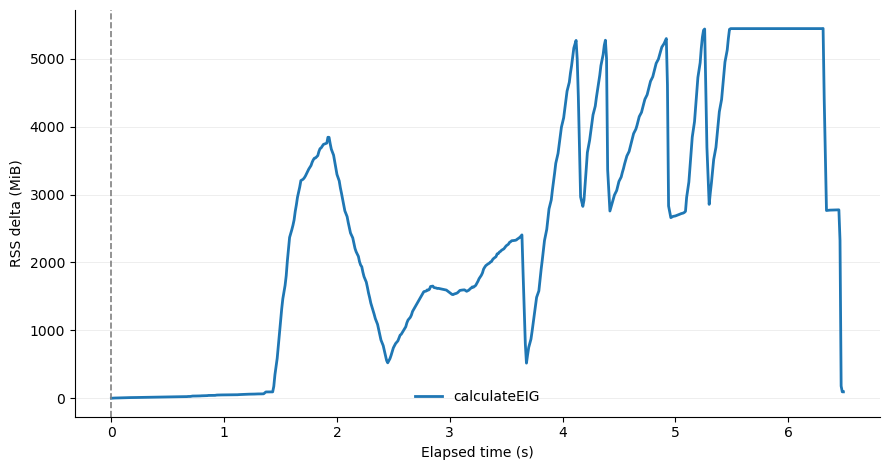

In [ ]:
designer = ExperimentDesigner(
    params,
    features,
    designs,
    unnorm_lfunc,
    lfunc_args={"sigma_y": 0.1}
)

out = profile(
    lambda: designer.calculateEIG(prior),
    label="calculateEIG",
    plot=False,
    csv=False,
    metadata={
        "grid_size": int(params.axes_in["frequency"].size),
        "design_chunk_size": designer.design_subgrid,
    },
)

rows = combine_memory_traces([("calculateEIG", out["trace"])], time_bin_s=0.01)
plot_timeseries(rows, labels=["calculateEIG"])


In the `ExperimentDesigner`, we can set the design_chunk_size=1 to chunk the design space and calculate each design's EIG in sequence, the memory peak decreases significantly and JAX provides good efficiency for repeatedly calculating EIG on each chunk.

{'label': 'calculateEIG',
 'call_elapsed_s': 2.9922363340010634,
 'process_elapsed_s': 2.9930003749977914,
 'peak_rss_mb': 612.1875,
 'peak_rss_delta_mb': 236.953125}

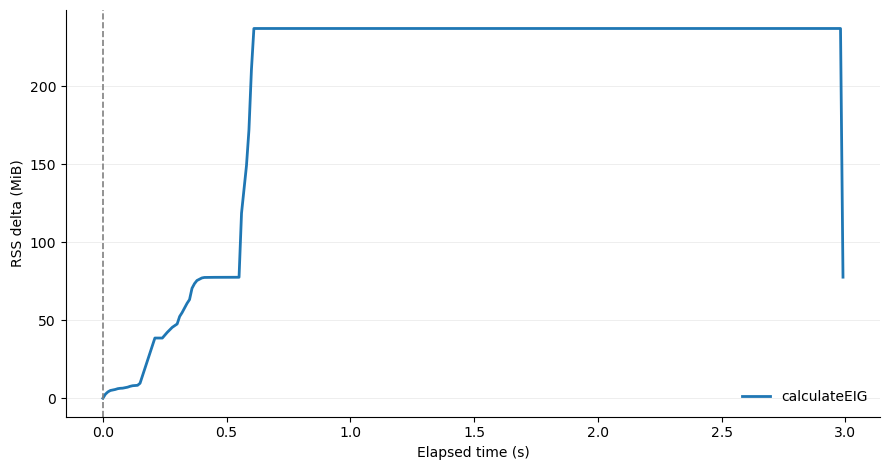

In [4]:
designer = ExperimentDesigner(
    params,
    features,
    designs,
    unnorm_lfunc,
    lfunc_args={"sigma_y": 0.1},
    design_chunk_size=1,
)

out = profile(
    lambda: designer.calculateEIG(prior),
    label="calculateEIG",
    plot=False,
    csv=False,
    metadata={
        "grid_size": int(params.axes_in["frequency"].size),
        "design_chunk_size": designer.design_subgrid,
    },
)

display(summarize_trace(out["trace"]))
rows = combine_memory_traces([("calculateEIG", out["trace"])], time_bin_s=0.01)
plot_timeseries(rows, labels=["calculateEIG"])

## Optional file outputs

Use the `out_dir` arg to save benchmark artifacts by passing it directly to `profile(...)`:

```python
out = profile(
    lambda: designer.calculateEIG(prior),
    out_dir="benchmark_results/eig_run",
    label="calculateEIG",
)
```

That writes `trace.json`, `trace.png`, and `summary.csv` under the directory you choose. Relative paths are resolved from wherever the notebook kernel is running.